In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('../data/processed/cleaned_supply_chain_no_fraud.csv', encoding = 'latin-1')

In [3]:
df.columns.to_list()

['Type',
 'Days for shipping (real)',
 'Days for shipment (scheduled)',
 'Benefit per order',
 'Sales per customer',
 'Delivery Status',
 'Late_delivery_risk',
 'Category Name',
 'Customer City',
 'Customer Country',
 'Customer Id',
 'Customer Segment',
 'Customer State',
 'Customer Zipcode',
 'Department Name',
 'Latitude',
 'Longitude',
 'Market',
 'Order City',
 'Order Country',
 'Order Customer Id',
 'order date (DateOrders)',
 'Order Id',
 'Order Item Discount',
 'Order Item Discount Rate',
 'Order Item Id',
 'Order Item Product Price',
 'Order Item Profit Ratio',
 'Order Item Quantity',
 'Sales',
 'Order Item Total',
 'Order Profit Per Order',
 'Order Region',
 'Order State',
 'Order Status',
 'Product Card Id',
 'Product Name',
 'Product Price',
 'Product Status',
 'shipping date (DateOrders)',
 'Shipping Mode']

In [4]:
df['shipping date (DateOrders)'] = pd.to_datetime(df['shipping date (DateOrders)'])
df['order date (DateOrders)'] = pd.to_datetime(df['order date (DateOrders)'])

In [5]:
df.dtypes[['shipping date (DateOrders)','order date (DateOrders)']]

shipping date (DateOrders)    datetime64[ns]
order date (DateOrders)       datetime64[ns]
dtype: object

In [6]:
df['order_month'] = df['order date (DateOrders)'].dt.to_period('M')

In [7]:
#build demand variability piece
category_monthly = df.groupby(['Category Name', 'order_month'])['Order Item Quantity'].sum().reset_index()
category_stats = category_monthly.groupby('Category Name')['Order Item Quantity'].agg(['mean', 'std']).reset_index()
category_stats

,Category Name,mean,std
0,Accessories,186.892857,27.140702
1,As Seen on TV!,34.333333,21.125025
2,Baby,100.500000,28.991378
3,Baseball & Softball,53.272727,23.207317
4,Basketball,32.000000,33.941125
5,Books,197.000000,152.735065
6,Boxing & MMA,37.484848,21.613250
7,CDs,133.000000,4.242641
8,Cameras,288.000000,383.251875
9,Camping & Hiking,394.823529,69.305416


In [8]:
category_stats['cv'] = category_stats['std']/category_stats['mean']
category_stats.sort_values('cv',ascending = False)

,Category Name,mean,std,cv
8,Cameras,288.000000,383.251875,1.330736
16,DVDs,155.666667,179.447300,1.152766
4,Basketball,32.000000,33.941125,1.060660
33,Men's Clothing,101.500000,101.116270,0.996219
11,Children's Clothing,316.500000,267.993470,0.846741
20,Garden,237.000000,199.404112,0.841368
13,Computers,215.500000,177.483802,0.823591
41,Strength Training,15.714286,12.566016,0.799656
5,Books,197.000000,152.735065,0.775305
14,Consumer Electronics,141.666667,92.522069,0.653097


In [12]:
df['Category Name'] = df['Category Name'].str.strip()

In [13]:
cameras_df = df[df['Category Name'] == 'Cameras'].copy()

cameras_daily = cameras_df.groupby(cameras_df['order date (DateOrders)'].dt.date)['Order Item Quantity'].sum()
daily_mean = cameras_daily.mean()
daily_std = cameras_daily.std()
avg_lead_time = cameras_df['Days for shipping (real)'].mean()

print(f"Daily mean demand : {daily_mean:.2f}")
print(f"Daily std demand: {daily_std:.2f}")
print(f"Average lead time (days): {avg_lead_time:.2f}")

Daily mean demand : 57.60
Daily std demand: 17.77
Average lead time (days): 3.33


In [10]:
cameras_df.shape

(0, 42)

In [11]:
df['Category Name'].unique()

array(['Sporting Goods', 'Cleats', 'Shop By Sport', "Women's Apparel",
       'Electronics', 'Boxing & MMA', 'Cardio Equipment', 'Trade-In',
       "Kids' Golf Clubs", 'Hunting & Shooting', 'Baseball & Softball',
       "Men's Footwear", 'Camping & Hiking', 'Consumer Electronics',
       'Cameras ', 'Computers', 'Basketball', 'Soccer', 'Accessories',
       "Girls' Apparel", "Women's Clothing", 'Crafts', "Men's Clothing",
       'Tennis & Racquet', 'Fitness Accessories', 'As Seen on  TV!',
       'Golf Balls', 'Strength Training', "Children's Clothing",
       'Lacrosse', 'Baby ', 'Fishing', 'Books ', 'DVDs', 'CDs ', 'Garden',
       'Hockey', 'Pet Supplies', 'Health and Beauty', 'Music',
       'Video Games', 'Golf Gloves', 'Golf Bags & Carts', 'Golf Shoes',
       'Golf Apparel', "Women's Golf Clubs", "Men's Golf Clubs", 'Toys',
       'Water Sports', 'Indoor/Outdoor Games'], dtype=object)

In [14]:
df['Category Name'].nunique()

50

In [15]:
#default to 95% service level
Z = 1.65
safety_stock_cameras = Z * daily_std * (avg_lead_time ** 0.5)
print(f"Recommended safety stock for Cameras: {safety_stock_cameras:.1f} units")

Recommended safety stock for Cameras: 53.5 units


In [19]:
cleats_df = df[df['Category Name'] == 'Cleats'].copy()

cleats_daily = cleats_df.groupby(cleats_df['order date (DateOrders)'].dt.date)['Order Item Quantity'].sum()
daily_mean = cleats_daily.mean()
daily_std = cleats_daily.std()
avg_lead_time = cleats_df['Days for shipping (real)'].mean()

print(f"Daily mean demand : {daily_mean:.2f}")
print(f"Daily std demand : {daily_std:.2f}")
print(f"Average lead time (days): {avg_lead_time:.2f}")

Daily mean demand : 71.61
Daily std demand : 16.48
Average lead time (days): 3.50


In [20]:
safety_stock_cleats = 1.65*16.48*(3.50**0.5)
print(f"Recommended safety stock for Cleats: {safety_stock_cleats:.1f} units")

Recommended safety stock for Cleats: 50.9 units


### Despite Cleats selling roughly 8 times more units per day than Cameras, both require a similar absolute safety stock buffer, around 51 to 54 units. This is because Cameras demand is far more volatile relative to its own size. This confirms that safety stock decisions should be driven by demand variability, measured through coefficient of variation, rather than sales volume alone. A high volume category is not automatically a low risk one.

In [21]:
results = []

for category in df['Category Name'].unique():
    cat_df = df[df['Category Name'] == category].copy()
    daily_demand = cat_df.groupby(cat_df['order date (DateOrders)'].dt.date)['Order Item Quantity'].sum()
    
    mean_demand = daily_demand.mean()
    std_demand = daily_demand.std()
    lead_time = cat_df['Days for shipping (real)'].mean()
    
    safety_stock = 1.65 * std_demand * (lead_time ** 0.5)
    
    results.append({
        'Category Name': category,
        'daily_mean': mean_demand,
        'daily_std': std_demand,
        'lead_time': lead_time,
        'safety_stock': safety_stock
    })

safety_stock_df = pd.DataFrame(results)
safety_stock_df['cv'] = safety_stock_df['daily_std'] / safety_stock_df['daily_mean']
safety_stock_df.sort_values('safety_stock', ascending=False)

,Category Name,daily_mean,daily_std,lead_time,safety_stock,cv
32,Books,43.777778,28.542853,3.411168,86.982692,0.651994
34,CDs,44.333333,27.983328,3.428571,85.494842,0.631203
39,Music,47.555556,27.744869,3.481308,85.415734,0.583420
33,DVDs,46.700000,26.432514,3.642398,83.236944,0.566007
30,Baby,40.200000,28.278967,3.139303,82.673085,0.703457
47,Toys,47.454545,25.484755,3.503831,78.711104,0.537035
38,Health and Beauty,43.875000,25.176165,3.470085,77.382652,0.573816
0,Sporting Goods,43.125000,24.982494,3.486957,76.973813,0.579304
28,Children's Clothing,52.750000,21.612812,3.616114,67.813515,0.409722
40,Video Games,55.000000,21.444280,3.595152,67.089416,0.389896


### Safety stock ranking does not match the coefficient of variation ranking directly. This is expected, not a contradiction. Coefficient of variation measures how erratic a category is relative to its own size, while the safety stock formula depends on the actual standard deviation in raw units, since that is what a warehouse physically needs to hold as buffer. A category like Soccer has a high coefficient of variation but a very small daily volume, so its absolute swings are small in real terms. A category like Books has a more moderate coefficient of variation but a much larger daily volume, so its absolute swings are larger and require more physical buffer stock. Both measures are correct, they simply answer different questions. Coefficient of variation identifies which categories are relatively unpredictable. Safety stock quantifies how many actual units are needed to buffer against that unpredictability given the category's real scale.

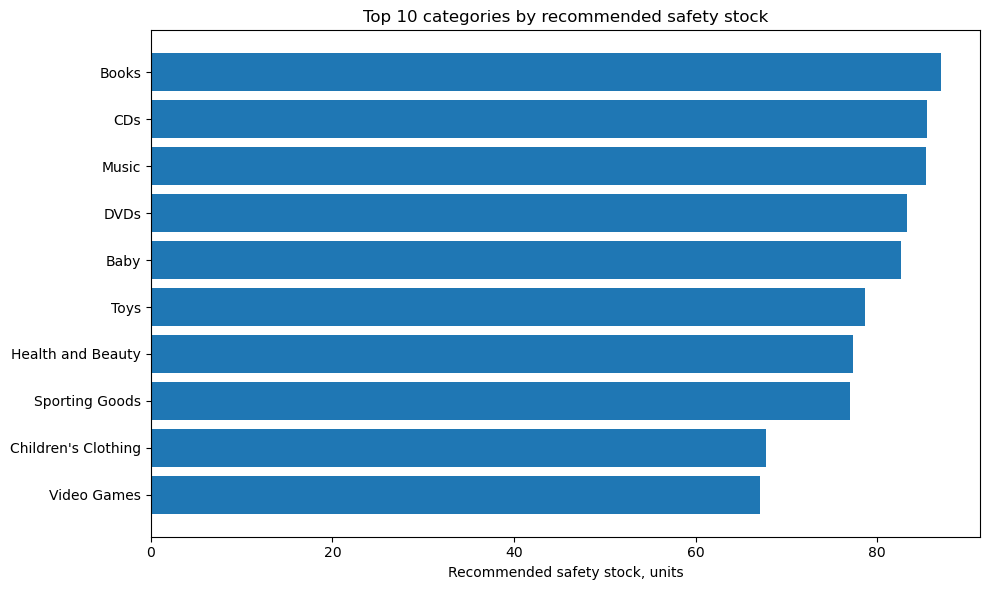

In [23]:
import matplotlib.pyplot as plt

top10 = safety_stock_df.sort_values('safety_stock', ascending=False).head(10)

plt.figure(figsize=(10, 6))
plt.barh(top10['Category Name'], top10['safety_stock'])
plt.xlabel('Recommended safety stock, units')
plt.title('Top 10 categories by recommended safety stock')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../reports/figures/safety_stock_top10.png')
plt.show()